# Stage 1 — Dataset Loading and Initial Inspection

This stage focuses on loading the loan application dataset and performing an initial inspection to understand its structure, columns, data types, missing values, and duplicate records before starting data preprocessing.

In [3]:
# cell 1: Import pandas for data handling
import pandas as pd

In [4]:
# Cell 2: Load the loan approval dataset

df = pd.read_csv("../data/loan_approval_data.csv")

# Display the first 5 rows
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [5]:
# Cell 3: Check the dataset dimensions

print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 20)


In [6]:
# Cell 4: Check the column names

print("Column Names:")
print(df.columns.tolist())

Column Names:
['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Employment_Status', 'Age', 'Marital_Status', 'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved']


In [7]:
# Cell 5: Check the data types of all columns

print("Data Types:")
print(df.dtypes)

Data Types:
Applicant_ID          float64
Applicant_Income      float64
Coapplicant_Income    float64
Employment_Status         str
Age                   float64
Marital_Status            str
Dependents            float64
Credit_Score          float64
Existing_Loans        float64
DTI_Ratio             float64
Savings               float64
Collateral_Value      float64
Loan_Amount           float64
Loan_Term             float64
Loan_Purpose              str
Property_Area             str
Education_Level           str
Gender                    str
Employer_Category         str
Loan_Approved             str
dtype: object


In [8]:
# Cell 6: Check for missing values

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64


In [9]:
# Cell 7: Check for duplicate records

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Stage 2 — Data Cleaning and Preprocessing

This stage focuses on handling missing values, removing duplicate records, preparing categorical and numerical features, transforming the target variable, and preparing the dataset for machine learning.

In [10]:
# Cell 1: Create a copy of the original dataset

df_clean = df.copy()

In [11]:
# Cell 2: Check missing values in the copied dataset

print("Missing Values Before Cleaning:")
print(df_clean.isnull().sum())

Missing Values Before Cleaning:
Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64


In [13]:
# Cell 3: Handle missing values in numerical columns

numerical_columns = df_clean.select_dtypes(include="number").columns

df_clean[numerical_columns] = df_clean[numerical_columns].fillna(
    df_clean[numerical_columns].median()
)

In [14]:
# Cell 4: Check remaining missing values

print("Missing Values After Numerical Cleaning:")
print(df_clean.isnull().sum())

Missing Values After Numerical Cleaning:
Applicant_ID           0
Applicant_Income       0
Coapplicant_Income     0
Employment_Status     50
Age                    0
Marital_Status        50
Dependents             0
Credit_Score           0
Existing_Loans         0
DTI_Ratio              0
Savings                0
Collateral_Value       0
Loan_Amount            0
Loan_Term              0
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64


In [15]:
# Cell 5: Remove records with missing loan approval status

df_clean = df_clean.dropna(subset=["Loan_Approved"])

In [16]:
# Cell 6: Handle missing values in categorical columns

categorical_columns = df_clean.select_dtypes(include="str").columns

for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])

In [17]:
# Cell 7: Check remaining missing values

print("Missing Values After Cleaning:")
print(df_clean.isnull().sum())

Missing Values After Cleaning:
Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64


In [18]:
# Cell 8: Encode categorical features

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = df_clean.select_dtypes(include="str").columns

for column in categorical_columns:
    df_clean[column] = label_encoder.fit_transform(df_clean[column])

In [19]:
# Cell 9: Separate features and target variable

X = df_clean.drop(columns=["Applicant_ID", "Loan_Approved"])
y = df_clean["Loan_Approved"]

In [20]:
# Cell 10: Scale the input features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [21]:
# Cell 11: Check the shape of the processed features and target

print("Features Shape:", X_scaled.shape)
print("Target Shape:", y.shape)

Features Shape: (950, 18)
Target Shape: (950,)


In [22]:
# Cell 12: Display the processed feature data

print("Processed Features:")
print(X_scaled[:5])

Processed Features:
[[ 1.41172858 -1.28699629 -0.17986571  1.00512972 -0.7380484  -1.33153075
  -0.55074064  1.49657598  1.30061671  1.65535897  1.50252999 -0.34535673
   1.5238463   1.49648842  0.88881111  1.60776418 -1.26599357  0.68814808]
 [-1.61626065 -0.83537914 -0.17986571  0.54649704 -0.7380484   1.44655317
  -0.78106827  0.03537641 -0.33253513 -1.29429995  1.76308802  1.62183015
   0.         -0.57994391 -0.25843149 -0.62198176  0.78989343  0.68814808]
 [-0.69782803 -1.03567064 -0.17986571 -1.37976021  1.35492468  0.5205252
  -0.01810799  1.49657598 -1.04260115  0.6806723  -1.27441345  0.66408791
   1.01589753 -1.27208801  0.88881111 -0.62198176 -1.26599357 -0.92007007]
 [ 0.63501437  1.0850424  -0.17986571 -0.00386217 -0.7380484   0.5205252
  -1.38567829  0.7659762  -0.26152853 -0.07168973 -0.992202    0.65303429
   0.50794877 -1.27208801 -1.40567409 -0.62198176 -1.26599357 -0.92007007]
 [ 0.4971481  -0.29567567  0.99049336 -0.82940099  1.35492468  0.5205252
   0.65847942 -0.

# Stage 3 — Exploratory Data Analysis (EDA)

This stage focuses on exploring the loan application dataset through statistical summaries and visualizations to understand applicant characteristics, financial factors, loan approval patterns, category-wise approval rates, and relationships between numerical features.

In [23]:
# Cell 1: Display statistical summary of numerical features

df_clean.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,498.578947,10831.908421,5068.877895,1.153684,40.042105,0.352632,1.437895,675.257895,1.951579,0.346832,9961.873158,24682.230526,20493.228947,48.000000,1.837895,1.225263,0.278947,0.615789,2.144211,0.313684
std,283.205473,4934.914103,2862.337127,0.854889,10.907713,0.478041,1.080450,69.502855,1.369459,0.140906,5706.375441,13954.335446,11223.958471,23.636874,1.445547,0.872114,0.448718,0.486664,1.244267,0.464234
min,1.000000,2009.000000,1.000000,0.000000,21.000000,0.000000,0.000000,550.000000,0.000000,0.100000,73.000000,36.000000,1015.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,255.250000,6896.500000,2687.750000,1.000000,31.000000,0.000000,1.000000,618.000000,1.000000,0.230000,4976.000000,13146.000000,10439.250000,24.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,499.500000,10548.000000,5205.500000,1.000000,40.000000,0.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000,2.000000,2.000000,0.000000,1.000000,3.000000,0.000000
75%,736.750000,14966.750000,7434.250000,2.000000,49.000000,1.000000,2.000000,733.000000,3.000000,0.470000,14771.500000,36255.750000,29586.000000,72.000000,3.000000,2.000000,1.000000,1.000000,3.000000,1.000000
max,1000.000000,19988.000000,9996.000000,3.000000,59.000000,1.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000,4.000000,2.000000,1.000000,1.000000,4.000000,1.000000


In [24]:
# Cell 2: Import libraries for data visualization

import matplotlib.pyplot as plt
import seaborn as sns

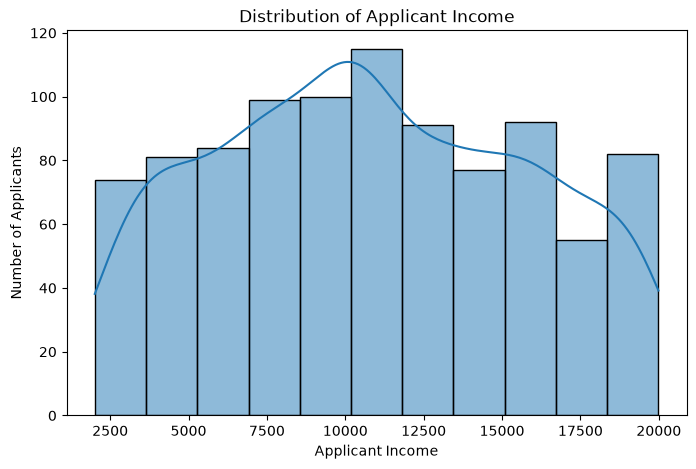

In [25]:
# Cell 3: Plot the distribution of applicant income

plt.figure(figsize=(8, 5))
sns.histplot(df_clean["Applicant_Income"], kde=True)

plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Number of Applicants")
plt.show()

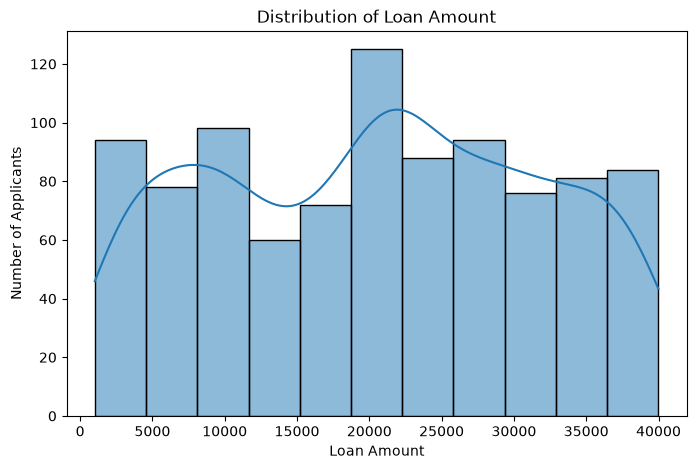

In [26]:
# Cell 4: Plot the distribution of loan amounts

plt.figure(figsize=(8, 5))
sns.histplot(df_clean["Loan_Amount"], kde=True)

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")
plt.show()

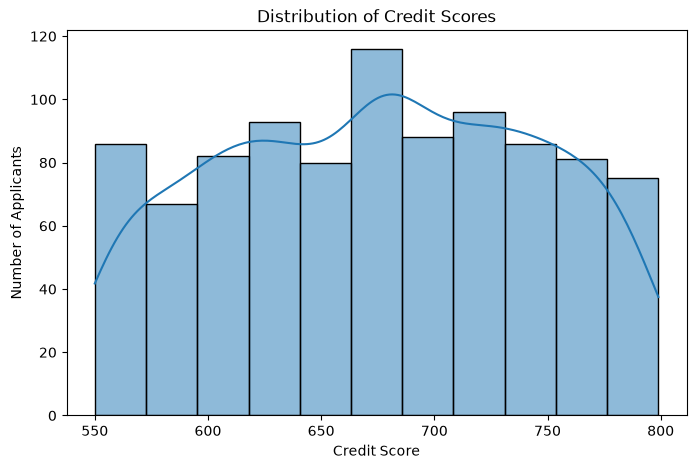

In [27]:
# Cell 5: Plot the distribution of credit scores

plt.figure(figsize=(8, 5))
sns.histplot(df_clean["Credit_Score"], kde=True)

plt.title("Distribution of Credit Scores")
plt.xlabel("Credit Score")
plt.ylabel("Number of Applicants")
plt.show()

In [28]:
# Cell 6: Calculate the overall loan approval rate

approval_rate = df_clean["Loan_Approved"].mean() * 100

print(f"Loan Approval Rate: {approval_rate:.2f}%")

Loan Approval Rate: 31.37%


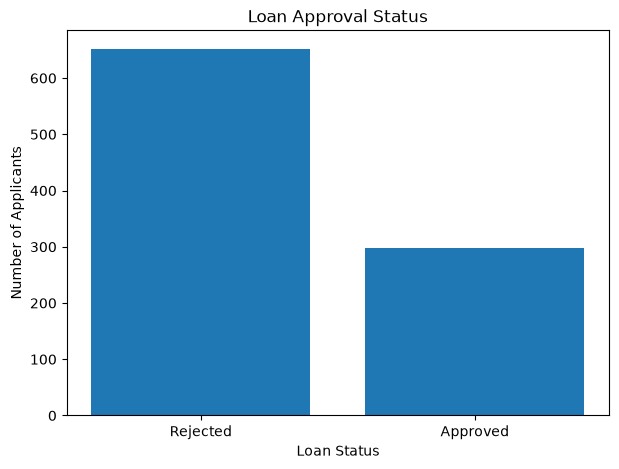

In [29]:
# Cell 7: Visualize loan approval status

approval_counts = df_clean["Loan_Approved"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["Rejected", "Approved"], approval_counts.values)

plt.title("Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.show()

In [30]:
# Cell 8: Compare loan approval rates by employment status

approval_by_employment = df_clean.groupby("Employment_Status")["Loan_Approved"].mean() * 100

print("Approval Rate by Employment Status:")
print(approval_by_employment)

Approval Rate by Employment Status:
Employment_Status
0    39.698492
1    29.268293
2    31.213873
3    24.418605
Name: Loan_Approved, dtype: float64


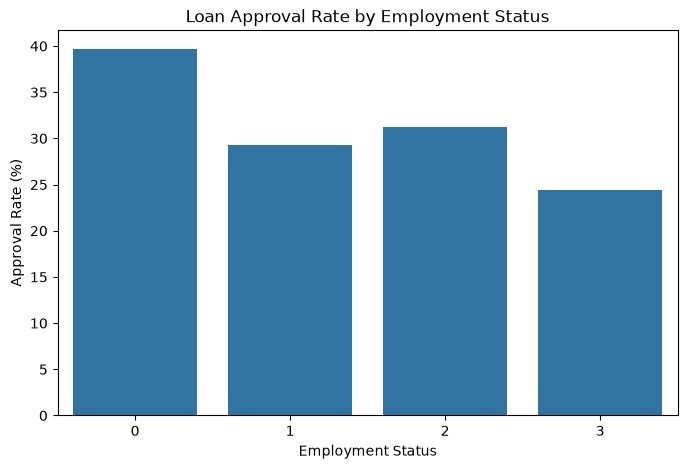

In [31]:
# Cell 9: Visualize approval rates by employment status

plt.figure(figsize=(8, 5))
sns.barplot(x=approval_by_employment.index, y=approval_by_employment.values)

plt.title("Loan Approval Rate by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Approval Rate (%)")
plt.show()

In [32]:
# Cell 10: Calculate approval rates by property area

approval_by_property = df_clean.groupby("Property_Area")["Loan_Approved"].mean() * 100

print("Approval Rate by Property Area:")
print(approval_by_property)

Approval Rate by Property Area:
Property_Area
0    30.215827
1    30.000000
2    32.520325
Name: Loan_Approved, dtype: float64


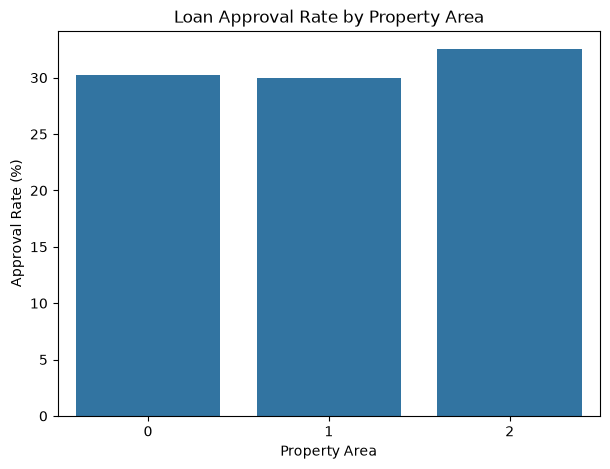

In [33]:
# Cell 11: Visualize approval rates by property area

plt.figure(figsize=(7, 5))
sns.barplot(x=approval_by_property.index, y=approval_by_property.values)

plt.title("Loan Approval Rate by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Approval Rate (%)")
plt.show()

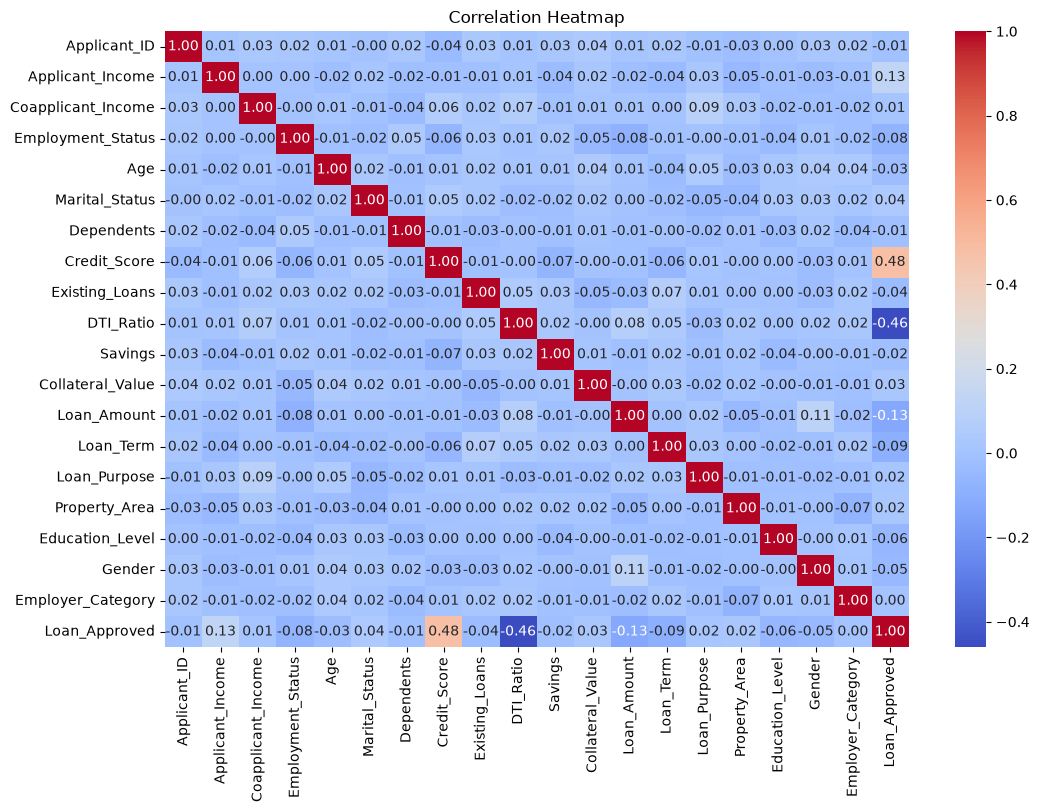

In [34]:
# Cell 12: Create a correlation heatmap for numerical features

plt.figure(figsize=(12, 8))

correlation_matrix = df_clean.select_dtypes(include="number").corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [35]:
# Cell 13: Compare loan approval rates by education level

approval_by_education = df_clean.groupby("Education_Level")["Loan_Approved"].mean() * 100

print("Approval Rate by Education Level:")
print(approval_by_education)

Approval Rate by Education Level:
Education_Level
0    32.992701
1    27.169811
Name: Loan_Approved, dtype: float64


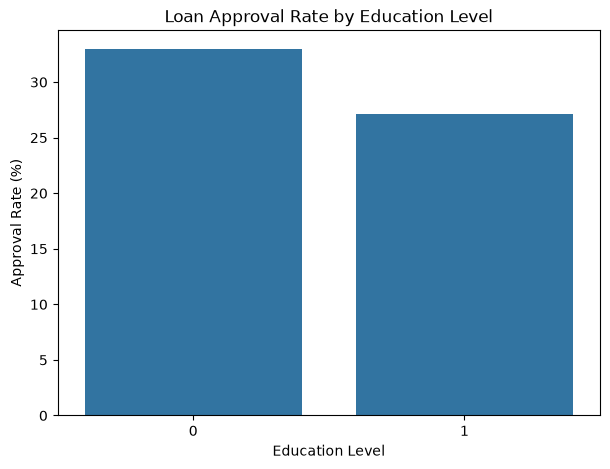

In [36]:
# Cell 14: Visualize approval rates by education level

plt.figure(figsize=(7, 5))
sns.barplot(x=approval_by_education.index, y=approval_by_education.values)

plt.title("Loan Approval Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Approval Rate (%)")
plt.show()

In [37]:
# Cell 15: Calculate approval rates by gender

approval_by_gender = df_clean.groupby("Gender")["Loan_Approved"].mean() * 100

print("Approval Rate by Gender:")
print(approval_by_gender)

Approval Rate by Gender:
Gender
0    34.246575
1    29.572650
Name: Loan_Approved, dtype: float64


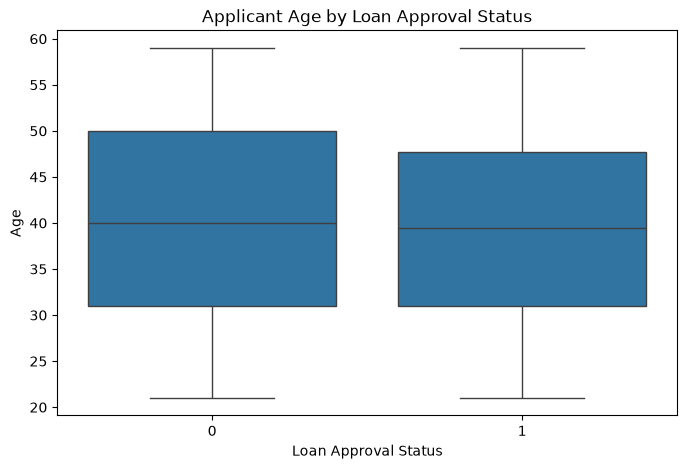

In [38]:
# Cell 16: Visualize loan approval by applicant age

plt.figure(figsize=(8, 5))
sns.boxplot(x="Loan_Approved", y="Age", data=df_clean)

plt.title("Applicant Age by Loan Approval Status")
plt.xlabel("Loan Approval Status")
plt.ylabel("Age")
plt.show()

# Stage 4 — Loan Approval Prediction Model

This stage focuses on preparing the processed dataset for machine learning and building classification models to predict whether a loan application will be approved or rejected. The required models are Logistic Regression, Decision Tree Classifier, Random Forest Classifier, and Support Vector Machine (SVM).

In [39]:
# Cell 1: Import the train-test split function

from sklearn.model_selection import train_test_split

In [40]:
# Cell 2: Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (760, 18)
Testing Features Shape: (190, 18)
Training Target Shape: (760,)
Testing Target Shape: (190,)


In [41]:
# Cell 3: Import the required classification models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [42]:
# Cell 4: Create the classification models

logistic_model = LogisticRegression(random_state=42)
decision_tree_model = DecisionTreeClassifier(random_state=42)
random_forest_model = RandomForestClassifier(random_state=42)
svm_model = SVC(random_state=42)

In [43]:
# Cell 5: Train the Logistic Regression model

logistic_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following a

In [44]:
# Cell 6: Train the Decision Tree model

decision_tree_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [45]:
# Cell 7: Train the Random Forest model

random_forest_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [46]:
# Cell 8: Train the Support Vector Machine model

svm_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


# Stage 5 — Model Training and Evaluation

This stage focuses on generating predictions from the trained classification models and comparing their performance on the test dataset using accuracy and other evaluation metrics.

In [47]:
# Cell 1: Import the accuracy score metric

from sklearn.metrics import accuracy_score

In [48]:
# Cell 2: Generate predictions from all trained models

logistic_predictions = logistic_model.predict(X_test)
decision_tree_predictions = decision_tree_model.predict(X_test)
random_forest_predictions = random_forest_model.predict(X_test)
svm_predictions = svm_model.predict(X_test)

In [49]:
# Cell 3: Calculate the accuracy of each model

logistic_accuracy = accuracy_score(y_test, logistic_predictions)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_predictions)
random_forest_accuracy = accuracy_score(y_test, random_forest_predictions)
svm_accuracy = accuracy_score(y_test, svm_predictions)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")
print(f"Decision Tree Accuracy: {decision_tree_accuracy:.4f}")
print(f"Random Forest Accuracy: {random_forest_accuracy:.4f}")
print(f"SVM Accuracy: {svm_accuracy:.4f}")

Logistic Regression Accuracy: 0.8737
Decision Tree Accuracy: 0.9421
Random Forest Accuracy: 0.9421
SVM Accuracy: 0.8789


In [50]:
# Cell 4: Create a model accuracy comparison table

model_accuracy = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        svm_accuracy
    ]
})

model_accuracy

,Model,Accuracy
0,Logistic Regression,0.873684
1,Decision Tree,0.942105
2,Random Forest,0.942105
3,SVM,0.878947


# Stage 6 — Detailed Model Evaluation

This stage focuses on evaluating the classification models using accuracy, precision, recall, F1-score, and confusion matrices to understand their prediction performance in more detail.

In [51]:
# Cell 1: Import detailed evaluation metrics

from sklearn.metrics import precision_score, recall_score, f1_score

In [52]:
# Cell 2: Calculate precision, recall, and F1-score for each model

logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)

decision_tree_precision = precision_score(y_test, decision_tree_predictions)
decision_tree_recall = recall_score(y_test, decision_tree_predictions)
decision_tree_f1 = f1_score(y_test, decision_tree_predictions)

random_forest_precision = precision_score(y_test, random_forest_predictions)
random_forest_recall = recall_score(y_test, random_forest_predictions)
random_forest_f1 = f1_score(y_test, random_forest_predictions)

svm_precision = precision_score(y_test, svm_predictions)
svm_recall = recall_score(y_test, svm_predictions)
svm_f1 = f1_score(y_test, svm_predictions)

print("Logistic Regression:")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall: {logistic_recall:.4f}")
print(f"F1-Score: {logistic_f1:.4f}")

print("\nDecision Tree:")
print(f"Precision: {decision_tree_precision:.4f}")
print(f"Recall: {decision_tree_recall:.4f}")
print(f"F1-Score: {decision_tree_f1:.4f}")

print("\nRandom Forest:")
print(f"Precision: {random_forest_precision:.4f}")
print(f"Recall: {random_forest_recall:.4f}")
print(f"F1-Score: {random_forest_f1:.4f}")

print("\nSVM:")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall: {svm_recall:.4f}")
print(f"F1-Score: {svm_f1:.4f}")

Logistic Regression:
Precision: 0.8462
Recall: 0.7333
F1-Score: 0.7857

Decision Tree:
Precision: 0.9016
Recall: 0.9167
F1-Score: 0.9091

Random Forest:
Precision: 0.8889
Recall: 0.9333
F1-Score: 0.9106

SVM:
Precision: 0.8936
Recall: 0.7000
F1-Score: 0.7850


In [53]:
# Cell 3: Create a detailed model performance comparison table

model_metrics = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        svm_accuracy
    ],
    "Precision": [
        logistic_precision,
        decision_tree_precision,
        random_forest_precision,
        svm_precision
    ],
    "Recall": [
        logistic_recall,
        decision_tree_recall,
        random_forest_recall,
        svm_recall
    ],
    "F1-Score": [
        logistic_f1,
        decision_tree_f1,
        random_forest_f1,
        svm_f1
    ]
})

model_metrics

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.873684,0.846154,0.733333,0.785714
1,Decision Tree,0.942105,0.901639,0.916667,0.909091
2,Random Forest,0.942105,0.888889,0.933333,0.910569
3,SVM,0.878947,0.893617,0.700000,0.785047


In [54]:
# Cell 4: Import the confusion matrix function

from sklearn.metrics import confusion_matrix

In [56]:
# Cell 5: Calculate confusion matrices for all models

logistic_cm = confusion_matrix(y_test, logistic_predictions)
decision_tree_cm = confusion_matrix(y_test, decision_tree_predictions)
random_forest_cm = confusion_matrix(y_test, random_forest_predictions)
svm_cm = confusion_matrix(y_test, svm_predictions)

print("Logistic Regression Confusion Matrix:")
print(logistic_cm)

print("\nDecision Tree Confusion Matrix:")
print(decision_tree_cm)

print("\nRandom Forest Confusion Matrix:")
print(random_forest_cm)

print("\nSVM Confusion Matrix:")
print(svm_cm)

Logistic Regression Confusion Matrix:
[[122   8]
 [ 16  44]]

Decision Tree Confusion Matrix:
[[124   6]
 [  5  55]]

Random Forest Confusion Matrix:
[[123   7]
 [  4  56]]

SVM Confusion Matrix:
[[125   5]
 [ 18  42]]


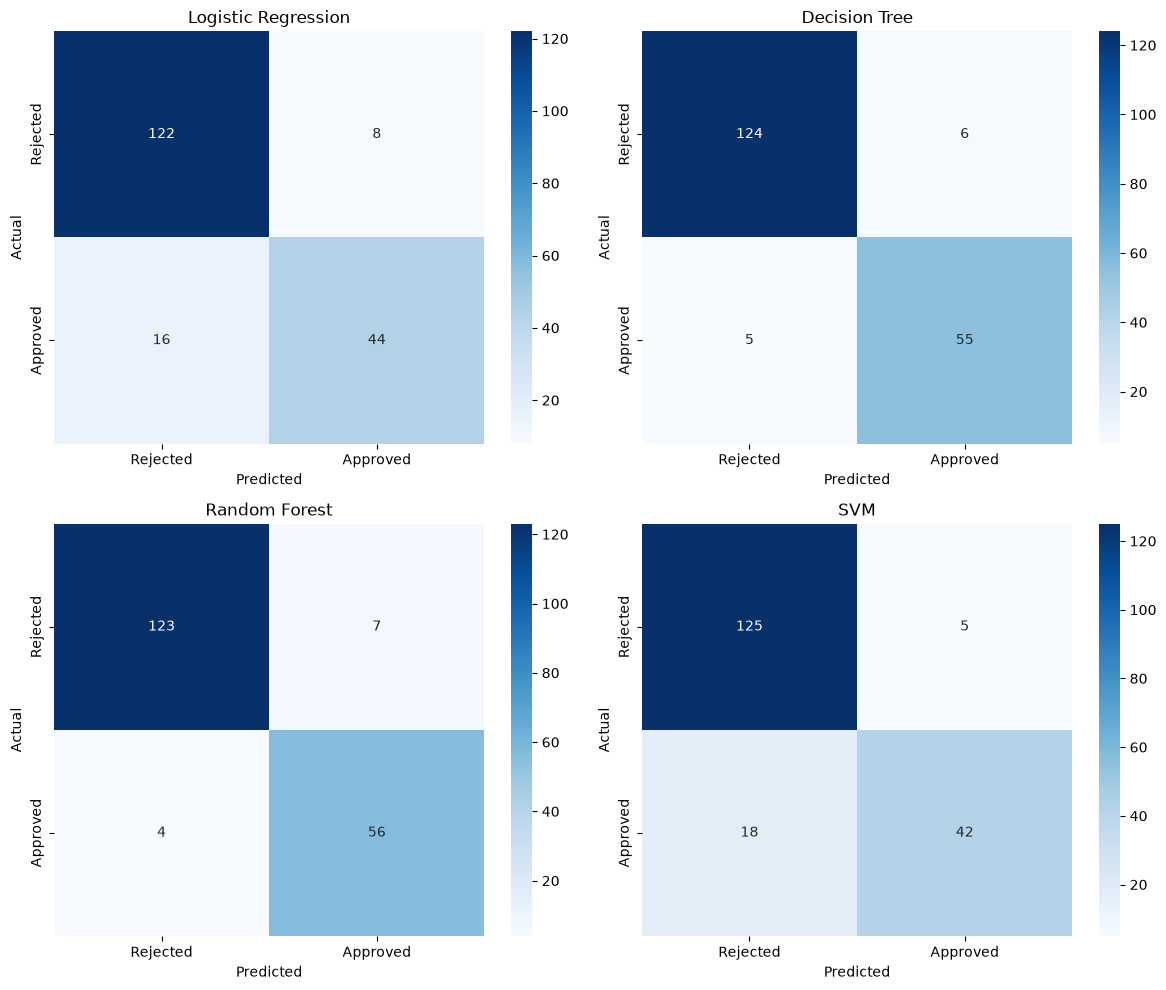

In [57]:
# Cell 6: Visualize the confusion matrices for all models

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

confusion_matrices = [
    (logistic_cm, "Logistic Regression"),
    (decision_tree_cm, "Decision Tree"),
    (random_forest_cm, "Random Forest"),
    (svm_cm, "SVM")
]

for ax, (cm, title) in zip(axes.ravel(), confusion_matrices):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Rejected", "Approved"],
        yticklabels=["Rejected", "Approved"],
        ax=ax
    )
    
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Stage 7 — Model Preparation for Streamlit

This stage focuses on preparing the trained machine learning model and preprocessing components so they can be used by the Streamlit application for predicting loan approval from new applicant details.

In [58]:
# Cell 1: Import joblib for saving the trained model and preprocessing object

import joblib

In [59]:
# Cell 2: Save the Random Forest model

joblib.dump(random_forest_model, "../models/random_forest_model.pkl")

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [60]:
# Cell 3: Save the feature scaler

joblib.dump(scaler, "../models/scaler.pkl")

print("Feature scaler saved successfully.")

Feature scaler saved successfully.


In [63]:
# Cell 4: Create and save encoding mappings consistent with LabelEncoder

encoding_mappings = {}

categorical_columns = [
    "Employment_Status",
    "Marital_Status",
    "Loan_Purpose",
    "Property_Area",
    "Education_Level",
    "Gender",
    "Employer_Category"
]

for column in categorical_columns:
    categories = sorted(df[column].dropna().unique())
    
    encoding_mappings[column] = {
        str(category): index
        for index, category in enumerate(categories)
    }

joblib.dump(encoding_mappings, "../models/encoding_mappings.pkl")

print("Encoding mappings saved successfully.")

Encoding mappings saved successfully.


In [65]:
# Cell 5: Verify the saved model and preprocessing files

import os

model_files = [
    "../models/random_forest_model.pkl",
    "../models/scaler.pkl",
    "../models/encoding_mappings.pkl"
]

for file in model_files:
    print(file, "->", "Found" if os.path.exists(file) else "Not Found")

../models/random_forest_model.pkl -> Found
../models/scaler.pkl -> Found
../models/encoding_mappings.pkl -> Found


In [66]:
# Cell 6: Display the encoding mappings used by the model

print("Encoding Mappings:")

for column, mapping in encoding_mappings.items():
    print(f"\n{column}:")
    print(mapping)

Encoding Mappings:

Employment_Status:
{'Contract': 0, 'Salaried': 1, 'Self-employed': 2, 'Unemployed': 3}

Marital_Status:
{'Married': 0, 'Single': 1}

Loan_Purpose:
{'Business': 0, 'Car': 1, 'Education': 2, 'Home': 3, 'Personal': 4}

Property_Area:
{'Rural': 0, 'Semiurban': 1, 'Urban': 2}

Education_Level:
{'Graduate': 0, 'Not Graduate': 1}

Gender:
{'Female': 0, 'Male': 1}

Employer_Category:
{'Business': 0, 'Government': 1, 'MNC': 2, 'Private': 3, 'Unemployed': 4}


In [67]:
# Cell 7: Check the prediction distribution of the trained Random Forest model

test_predictions = random_forest_model.predict(X_test)

print("Predicted Rejected:", (test_predictions == 0).sum())
print("Predicted Approved:", (test_predictions == 1).sum())

Predicted Rejected: 127
Predicted Approved: 63


In [69]:
# Cell 8: Find an approved prediction in the test dataset

test_predictions = random_forest_model.predict(X_test)

approved_positions = [i for i, prediction in enumerate(test_predictions) if prediction == 1]

print("First approved test position:", approved_positions[0])

First approved test position: 0


In [70]:
# Cell 9: Display the original details of an applicant predicted as approved

approved_index = y_test.index[approved_positions[0]]

print("Approved Applicant Details:")
print(df_clean.loc[approved_index])

print("\nModel Prediction: Approved")

Approved Applicant Details:
Applicant_ID            154.00
Applicant_Income       7791.00
Coapplicant_Income     7138.00
Employment_Status         0.00
Age                      47.00
Marital_Status            0.00
Dependents                2.00
Credit_Score            775.00
Existing_Loans            1.00
DTI_Ratio                 0.28
Savings                9880.50
Collateral_Value      23949.00
Loan_Amount           21505.00
Loan_Term                48.00
Loan_Purpose              0.00
Property_Area             0.00
Education_Level           1.00
Gender                    1.00
Employer_Category         2.00
Loan_Approved             1.00
Name: 153, dtype: float64

Model Prediction: Approved


In [71]:
# Cell 10: Save model performance metrics for the Streamlit dashboard

model_metrics.to_csv("../models/model_metrics.csv", index=False)

print("Model performance metrics saved successfully.")

Model performance metrics saved successfully.
